# Climate ELA recontruction of Carrasco et al., 2008 table 4 data and figure 8. simply reproduced

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

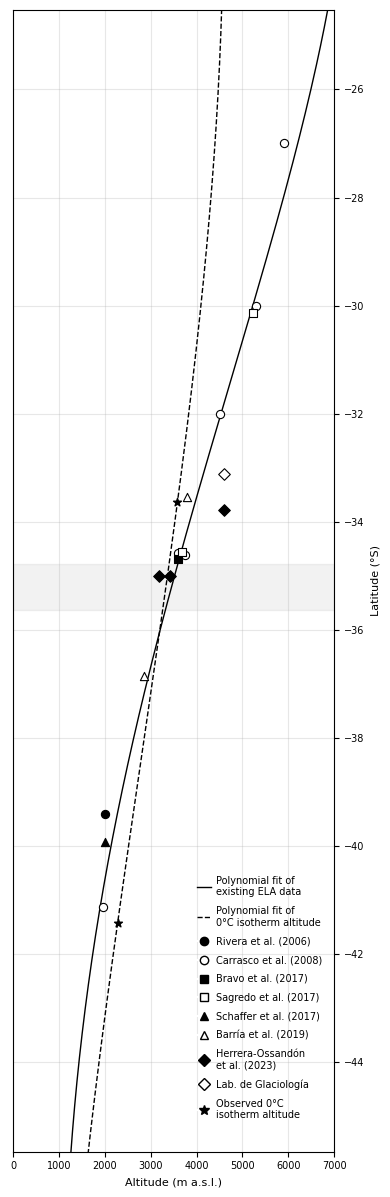

In [13]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Data ──────────────────────────────────────────────────────────────────────
# Groups:
# 0 = Rivera et al. (2006)
# 1 = Carrasco et al. (2008)
# 2 = Bravo et al. (2017)
# 3 = Sagredo et al. (2017)
# 4 = Schaffer et al. (2017)
# 5 = Barria et al. (2019)
# 6 = Herrera-Ossandon et al. (2023)
# 7 = Lab. de Glaciologia
#
# All coordinates verified against DMS in source papers:
# Tapado:      30°08'S  69°55'W  → -30.133  (was -30.14)
# Olivares Gamma: 33°07'S 70°10'W → -33.117  (Hanna et al. 2017)
# Palomo:      Barria (2019) Table 3: 34.58°S  (was -34.23, Carrasco value ~40 km wrong)
# Cortaderal:  Barria (2019) Table 3: 34.62°S  (was -34.26, Carrasco value ~40 km wrong)
# Cipreses:    34°34'S  70°21'W  → -34.567  (was -34.55)
# Universidad: AWS1 34°42'S 70°20'W → -34.700  (was -34.68)
# Nevados Chillan: summit 36°51'S 71°22'W → -36.858  (was -36.87)
# Villarrica:  39°25'12"S 71°56'27"W → -39.420  (was -39.43)
# Tranquilo:   47°33'S  72°23'W  → -47.550  (was -47.00, significantly wrong)
# Isotherm Santo Domingo: 33°38'S → -33.633  (was -32.47, old Quintero location)

ela_points = [
    # lat,      ELA,   group   # glacier / note
    (-13.800,   5220,  3),  # Vilcanota - Sagredo 2017 (mean AAR=0.7/0.8) | 13°48'S 70°59'W
    (-27.000,   5900,  1),  # Unknown - Hastenrath 1971 via Carrasco 2008 (no lon recorded)
    (-30.000,   5300,  1),  # Unknown - Hastenrath 1971 via Carrasco 2008 (no lon recorded)
    (-30.133,   5225,  3),  # Tapado - Sagredo 2017 (mean AAR=0.4/0.5) | 30°08'S 69°55'W
    (-32.000,   4500,  1),  # Unknown - Hastenrath 1971 via Carrasco 2008 (no lon recorded)
    (-33.117,   4600,  7),  # Olivares Gamma - Lab. de Glaciologia | 33°07'S 70°10'W
    (-33.550,   3800,  5),  # Echaurren Norte - Herrera 2016 thesis via Barria 2019
    (-33.780,   4600,  6),  # Maipo/Volcan catchment - Herrera-Ossandon 2023 | 33°47'S 70°05'W
    (-34.580,   3596,  1),  # Palomo - Barria (2019) Table 3: 34.58S 70.30W
    (-34.620,   3740,  1),  # Cortaderal - Barria (2019) Table 3: 34.62S 70.32W
    (-34.567,   3680,  3),  # Cipreses - Sagredo 2017 (mean AAR=0.55/0.65) | 34°34'S 70°21'W
    (-34.700,   3600,  2),  # Universidad - Bravo 2017 | AWS1: 34°42'S 70°20'W
    (-35.000,   3250,  6),  # Azufre - Espizua 1993 via Herrera-Ossandon 2023
    (-35.000,   3350,  6),  # El Penon - Espizua 1999 via Herrera-Ossandon 2023
    (-36.858,   2850,  5),  # Nevados de Chillan - Caro 2014 via Barria 2019 | 36°51'S 71°22'W
    (-39.420,   2000,  0),  # Volcan Villarrica - Rivera 2006 | 39°25'12"S 71°56'27"W
    (-39.930,   1993,  4),  # Mocho Choshuenco - Schaffer 2017 (stated 4-yr mean)
    (-41.130,   1958,  1),  # Casa Pangue - Bown 2004/Rivera 2000 via Carrasco 2008
    (-46.450,   1096,  1),  # Grosse
    (-46.470,   1257,  1),  # Rio Verde
    (-46.480,   1328,  1),  # Reicher
    (-46.500,   1187,  1),  # Exploradores
    (-46.550,   1087,  1),  # Gualas
    (-46.680,   1013,  1),  # San Rafael
    (-46.700,   1294,  1),  # Fiero
    (-46.770,   1322,  1),  # Leones
    (-46.870,    957,  1),  # San Quintin
    (-46.900,   1283,  1),  # Soler
    (-47.030,    908,  1),  # Benito
    (-47.100,   1303,  1),  # Cachet
    (-47.120,   1183,  1),  # Nef
    (-47.180,    959,  1),  # HPN 1
    (-47.250,   1302,  1),  # Colonia
    (-47.280,   1248,  1),  # Arco
    (-47.450,    975,  1),  # Pared Sur
    (-47.470,   1025,  1),  # Pared Norte
    (-47.480,   1065,  1),  # Piscis
    (-47.530,   1074,  1),  # Steffen
    (-47.550,   1865,  3),  # Tranquilo - Sagredo 2017 (mean AAR=0.55/0.66) | 47°33'S 72°23'W
    (-54.780,   1090,  1),  # Martial Este - Strelin & Iturraspe 2007 via Carrasco 2008
]

all_lats = [x[0] for x in ela_points]
all_ela  = [x[1] for x in ela_points]
groups   = [x[2] for x in ela_points]

# 0°C isotherm altitudes — Carrasco et al. (2008) Table 3, 1958-2006 means
# Coordinates corrected from DMS (Carrasco p1-p2):
#   Antofagasta:   23°26'S 70°26'W → -23.433
#   Santo Domingo: 33°38'S 71°18'W → -33.633  (moved from Quintero 32°47'S in 1999)
#   Puerto Montt:  41°26'S 73°07'W → -41.433
#   Punta Arenas:  53°00'S 70°07'W → -53.000
isotherm_lats = [-23.433, -33.633, -41.433, -53.000]
isotherm_alts = [ 4573,    3584,    2278,    1037]

lat_line = np.linspace(-57, -12, 400)

# Polynomial fits
z  = np.polyfit(all_lats, all_ela, 4)
p  = np.poly1d(z)
z2 = np.polyfit(isotherm_lats, isotherm_alts, 3)
p2 = np.poly1d(z2)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 12.07))

# Grey band — area of focus (~34.8-35.6 deg S)
ax.axhspan(-35.63, -34.78, color='grey', alpha=0.1)

# Polynomial fit lines
ax.plot(p(lat_line),  lat_line, color='black', lw=1.0, ls='-',  zorder=3)
ax.plot(p2(lat_line), lat_line, color='black', lw=1.0, ls='--', zorder=3)

# Marker styles per group
markers = {
    0: ('o', 'black', 'black', 'Rivera et al. (2006)'),
    1: ('o', 'white', 'black', 'Carrasco et al. (2008)'),
    2: ('s', 'black', 'black', 'Bravo et al. (2017)'),
    3: ('s', 'white', 'black', 'Sagredo et al. (2017)'),
    4: ('^', 'black', 'black', 'Schaffer et al. (2017)'),
    5: ('^', 'white', 'black', 'Barria et al. (2019)'),
    6: ('D', 'black', 'black', 'Herrera-Ossandon et al. (2023)'),
    7: ('D', 'white', 'black', 'Lab. de Glaciologia'),
}

for g, (mk, fc, ec, lbl) in markers.items():
    if g == 6:
        # Azufre and El Penon share lat=-35.00; jitter +/-75 m so both visible
        lats_g = [all_lats[i] for i in range(len(all_lats)) if groups[i] == g]
        elas_g  = [all_ela[i]  for i in range(len(all_ela))  if groups[i] == g]
        elas_j, lats_j = [], []
        seen_35 = 0
        for lat, ela in zip(lats_g, elas_g):
            if lat == -35.00:
                offset = -75 if seen_35 == 0 else 75
                seen_35 += 1
                elas_j.append(ela + offset)
            else:
                elas_j.append(ela)
            lats_j.append(lat)
        ax.scatter(elas_j, lats_j, marker=mk, facecolors=fc, edgecolors=ec,
                   s=35, linewidths=0.8, zorder=5)
    else:
        lats_g = [all_lats[i] for i in range(len(all_lats)) if groups[i] == g]
        elas_g  = [all_ela[i]  for i in range(len(all_ela))  if groups[i] == g]
        if lats_g:
            ax.scatter(elas_g, lats_g, marker=mk, facecolors=fc, edgecolors=ec,
                       s=35, linewidths=0.8, zorder=5)

# 0 deg C isotherm observed points
ax.scatter(isotherm_alts, isotherm_lats,
           color='black', s=35, marker='*', zorder=6)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], color='black', lw=1, ls='-',
           label='Polynomial fit of\nexisting ELA data'),
    Line2D([0],[0], color='black', lw=1, ls='--',
           label='Polynomial fit of\n0\u00b0C isotherm altitude'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=6, label='Rivera et al. (2006)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Carrasco et al. (2008)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=6, label='Bravo et al. (2017)'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Sagredo et al. (2017)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=6, label='Schaffer et al. (2017)'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Barr\u00eda et al. (2019)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=6,
           label='Herrera-Ossand\u00f3n\net al. (2023)'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=6, label='Lab. de Glaciolog\u00eda'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=7,
           label='Observed 0\u00b0C\nisotherm altitude'),
]

ax.set_xlabel('Altitude (m a.s.l.)', fontsize=8)
ax.set_ylabel('Latitude (\u00b0S)', fontsize=8)
ax.set_yticks(np.arange(-44, -25, 2))  # ticks at -26 to -44 every 2 degrees
ax.set_ylim(-45.663, -24.529)  # extent stays -46 to -24
ax.set_xlim(0, 7000)
ax.yaxis.set_label_position('right')
ax.yaxis.tick_right()
ax.tick_params(axis='both', labelsize=7)
ax.legend(handles=legend_elements, fontsize=7,
          bbox_to_anchor=(0.99, 0.02), loc='lower right',
          ncol=1, frameon=False,
          handlelength=1.5, handletextpad=0.5,
          labelspacing=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()

In [14]:
plt.savefig('ELA_plot.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

<Figure size 640x480 with 0 Axes>